# Assignment
Analyze and compare the air pollution data from 2 stations: one in New York City (US) and one in Bogota (Columbia). Extract useful insights and include visualizations that support your findings.

You can start by analyzing the data from each station individually. Perform a time series analysis on the pollution levels. When is pollution the highest and the lowest? Can you see any trends or seasonal patterns?

Next, you may compare the PM2.5 pollution in both cities. Using a visualization, show at what times is the pollution level in New York higher than in Bogota. Can you see any trends or seasonal patterns? Are the two time series correlated?

You are also encouraged to explore the pollution limits set by the World Health Organization (WHO), for example, based on this document. Is the annual mean pollution level in the two cities below the acceptable value defined by the WHO? Write an algorithm that detects the time when the 24-hour mean pollution level exceeds the acceptable value and use a visualization to demark these periods.

Above are just suggestions of what you can extract from these data. Still, after analyzing the datasets, feel free to use your imagination and draw additional insightful conclusions!

In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/biswasbarsha/air-pollution-analysis-datasets/datasets/StationData-NY_QueensCollege.txt
/kaggle/input/datasets/biswasbarsha/air-pollution-analysis-datasets/datasets/StationData-Bogota_SanCristobal.txt


# Data Loading

This step loads hourly PM2.5 air quality measurements from two different locations:

1. New York (Queens College)
2. Bogota (San Cristobal)

Both datasets are stored as .txt files and use the | character as a separator.
At this stage, the goal is only to bring the raw data into memory without any transformation.

In [3]:
import pandas as pd

df_ny = pd.read_csv("/kaggle/input/datasets/biswasbarsha/air-pollution-analysis-datasets/datasets/StationData-NY_QueensCollege.txt", sep = '|')
df_bg = pd.read_csv("/kaggle/input/datasets/biswasbarsha/air-pollution-analysis-datasets/datasets/StationData-Bogota_SanCristobal.txt", sep = '|')

## Data Exploration
This section is used to understand the structure, format, and quality of the raw dataset before any cleaning or analysis is performed.

### On New York Dataset

In [4]:
df_ny.head()

,Station:Queens College -,Date Time,PM25FEM
0,,,ug/m3
1,,9/1/2016 12:00 AM,9.9
2,,9/1/2016 1:00 AM,11.2
3,,9/1/2016 2:00 AM,10.3
4,,9/1/2016 3:00 AM,12.6


The first five rows show:

* A station name column
* A Date Time column stored as text
* PM2.5 values that appear numeric but are actually stored as strings
This indicates that the data is not yet in a format suitable for numerical analysis.

In [5]:
df_ny.tail()

,Station:Queens College -,Date Time,PM25FEM
5093,,Max Date,2/20/2017 1:00 PM
5094,,Avg,5.7
5095,,Num,4896
5096,,Data[%],96
5097,,STD,5.2


The last rows contain summary information such as:

* Maximum date
* Average PM2.5 value
* Number of observations
* Data completeness percentage
* Standard deviation

These rows are not actual measurements.
They will need to be removed during the cleaning phase.

In [6]:
print(df_ny.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5098 entries, 0 to 5097
Data columns (total 3 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Station:Queens College -     5098 non-null   object
 1    Date Time                   5098 non-null   object
 2    PM25FEM                     5098 non-null   object
dtypes: object(3)
memory usage: 119.6+ KB
None


Key observations from the structure:

* Total rows: 5098
* Total columns: 3
* All columns are of type object
* No missing values are detected at this stage
This confirms that both Date Time and PM2.5 values must be converted into proper numerical and datetime formats.

In [7]:
df_ny.describe()

,Station:Queens College -,Date Time,PM25FEM
count,5098,5098,5098
unique,1,5098,306
top,,STD,
freq,5098,1,193


Although a statistical summary is generated, the results are not fully reliable because:

* PM2.5 values are still stored as strings
* The dataset includes non-measurement summary rows at the bottom
True statistical analysis will only be valid after full data cleaning.

### On Bogota Dataset

In [8]:
df_bg.head()

,Estación:San Cristobal -,Fecha y Hora,PM2.5,PM10
0,,,µg/m3,µg/m3
1,,31-08-2016 24:00,"6,0","3,9"
2,,01-09-2016 1:00,"7,9","4,9"
3,,01-09-2016 2:00,"7,3","8,0"
4,,01-09-2016 3:00,"2,5","8,1"


The first rows reveal several important details:

* The station name is stored in Spanish.
* The Date and Time column uses the format dd-mm-yyyy HH:MM.
* A critical issue appears immediately: the time value 24:00 exists.
* PM2.5 and PM10 values use commas instead of dots as decimal separators.
These formatting issues will prevent direct datetime parsing and numerical analysis.

In [9]:
df_bg.tail()

,Estación:San Cristobal -,Fecha y Hora,PM2.5,PM10
5116,,Fecha Max,28-02-2017 18:00,11-02-2017 11:00
5117,,Prom.,"11,0","26,3"
5118,,Num,5014,4949
5119,,Dato[%],98,96
5120,,STD,"7,7","20,2"


The last rows contain summary information such as:

* Fecha Max
* Prom.
* Num
* Dato[%]
* STD

These rows are not actual measurements.
They will need to be removed during the cleaning phase.

In [10]:
print(df_bg.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5121 entries, 0 to 5120
Data columns (total 4 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Estación:San Cristobal -     5121 non-null   object
 1    Fecha y Hora                5121 non-null   object
 2    PM2.5                       5121 non-null   object
 3    PM10                        5121 non-null   object
dtypes: object(4)
memory usage: 160.2+ KB
None


Key observations from the dataset structure:

* Total rows: 5121
* Total columns: 4
* All columns are stored as object
* No missing values are detected at this stage


This confirms that:

* Date and time must be converted to proper datetime format
* PM2.5 and PM10 must be converted to numeric values

In [11]:
df_bg.describe()

,Estación:San Cristobal -,Fecha y Hora,PM2.5,PM10
count,5121,5121,5121,5121
unique,1,5121,365,735
top,,STD,"0,0",
freq,5121,1,462,163


The statistical summary shows:

* The station column has only one unique value
* Date column contains 5121 unique timestamps
* PM2.5 and PM10 contain hundreds of unique values

However, because the PM values are still stored as text:

*  The statistics are not yet fully reliable
* True min, max, and average values will only be correct after numeric conversion

# Data Wrangling
This section prepares both datasets for analysis by fixing structural problems, cleaning columns, and removing invalid rows. At this stage, no numerical transformations are applied yet. The focus is purely on data integrity.

## Clean Column and Rows
This step standardizes column names, removes unit rows, and filters out embedded summary records. The goal is to make sure that only real hourly air pollution measurements remain in both datasets.

## Convert Data Types
Now the datasets are converted from text-based formats into true numerical and datetime formats. This step is mandatory for all time series operations and statistical analysis.

In [12]:
print(df_ny.columns)
print(df_bg.columns)

Index(['Station:Queens College -  ', ' Date Time                 ',
       ' PM25FEM '],
      dtype='object')
Index(['Estación:San Cristobal -  ', ' Fecha y Hora              ',
       ' PM2.5    ', ' PM10    '],
      dtype='object')


There's an extra whitespaces which need to be removed.

In [13]:
# Strip column name whitespace
df_ny_clean = df_ny.columns.str.strip()
print(df_ny_clean)
df_bogota_clean = df_bg.columns.str.strip()
print(df_bogota_clean)

Index(['Station:Queens College -', 'Date Time', 'PM25FEM'], dtype='object')
Index(['Estación:San Cristobal -', 'Fecha y Hora', 'PM2.5', 'PM10'], dtype='object')


In [14]:
# Re-create the DataFrame from the original load
df_ny_clean = df_ny.copy()

# Fix the column names immediately
df_ny_clean.columns = ['Station', 'DateTime', 'PM2.5_NY']

# Remove the unit row (index 0) and the summary rows (Avg, STD, etc.) at once
# We do this by forcing the PM2.5 column to be numeric; text rows become NaT/NaN
df_ny_clean['PM2.5_NY'] = pd.to_numeric(df_ny_clean['PM2.5_NY'], errors='coerce')
df_ny_clean['DateTime'] = pd.to_datetime(df_ny_clean['DateTime'], errors='coerce')

# Now remove any rows that have NaT or NaN (this cleans the summary rows)
df_ny_clean = df_ny_clean.dropna(subset=['PM2.5_NY', 'DateTime'])

print(df_ny_clean.head())

/tmp/ipykernel_55/1944210668.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_ny_clean['DateTime'] = pd.to_datetime(df_ny_clean['DateTime'], errors='coerce')


  Station            DateTime  PM2.5_NY
1         2016-09-01 00:00:00       9.9
2         2016-09-01 01:00:00      11.2
3         2016-09-01 02:00:00      10.3
4         2016-09-01 03:00:00      12.6
5         2016-09-01 04:00:00       9.2


In [15]:
# Create a copy to avoid modifying the original
df_bogota_clean = df_bg.copy()

# Rename safely based on actual column count
bog_cols = df_bogota_clean.columns.tolist()
bog_cols[0] = 'Station'
bog_cols[1] = 'DateTime'
bog_cols[2] = 'PM2.5_Bog'
if len(bog_cols) > 3:
    bog_cols[3] = 'PM10_Bog'
df_bogota_clean.columns = bog_cols

# 1. Fix Bogota-specific numeric formatting (replace ',' with '.')
df_bogota_clean['PM2.5_Bog'] = df_bogota_clean['PM2.5_Bog'].astype(str).str.replace(',', '.')
df_bogota_clean['PM2.5_Bog'] = pd.to_numeric(df_bogota_clean['PM2.5_Bog'], errors='coerce')

# 2. Fix Bogota-specific numeric formatting (replace ',' with '.')
df_bogota_clean['PM10_Bog'] = df_bogota_clean['PM10_Bog'].astype(str).str.replace(',', '.')
df_bogota_clean['PM10_Bog'] = pd.to_numeric(df_bogota_clean['PM10_Bog'], errors='coerce')


# 3. Fix Bogota-specific time formatting (replace '24:00' with '00:00')
df_bogota_clean['DateTime'] = df_bogota_clean['DateTime'].astype(str).str.replace('24:00', '00:00')
df_bogota_clean['DateTime'] = pd.to_datetime(df_bogota_clean['DateTime'], errors='coerce')

# 4. Remove NaT (failed date parses) and NaN (summary rows like 'STD' or 'Avg')
df_bogota_clean = df_bogota_clean.dropna(subset=['DateTime', 'PM2.5_Bog'])

# Show result
df_bogota_clean.head()

/tmp/ipykernel_55/577045853.py:24: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_bogota_clean['DateTime'] = pd.to_datetime(df_bogota_clean['DateTime'], errors='coerce')


,Station,DateTime,PM2.5_Bog,PM10_Bog
1,,2016-08-31 00:00:00,6.0,3.9
2,,2016-01-09 01:00:00,7.9,4.9
3,,2016-01-09 02:00:00,7.3,8.0
4,,2016-01-09 03:00:00,2.5,8.1
5,,2016-01-09 04:00:00,6.5,7.3


In [16]:
# Remove summary rows
summary_keywords = [
    'Minimum', 'Maximum', 'Avg', 'Num', 'Data[%]', 'STD',
    'Min Date', 'Max Date',
    'Mínimo', 'Máximo', 'Prom.', 'Dato[%]', 'Fecha Min', 'Fecha Max'
]

df_ny_clean = df_ny_clean[~df_ny_clean['DateTime'].isin(summary_keywords)]
df_bogota_clean = df_bogota_clean[~df_bogota_clean['DateTime'].isin(summary_keywords)]

This step transforms the cleaned text-based columns into proper datetime and numeric formats. It also fixes critical timestamp errors that would break time series alignment.

In [17]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
# Fix 24:00 -> 00:00 issue
def fix_24h(dt_str):
    if '24:00' in str(dt_str):
        dt_str = dt_str.replace('24:00', '00:00')
        dt = pd.to_datetime(dt_str, dayfirst=True) + pd.Timedelta(days=1)
        return dt
    return pd.to_datetime(dt_str, dayfirst=True)

# Convert DateTime (apply fix to BOTH)
df_ny_clean['DateTime'] = df_ny_clean['DateTime'].apply(fix_24h)
df_bogota_clean['DateTime'] = df_bogota_clean['DateTime'].apply(fix_24h)

# Convert PM values to numeric
df_ny_clean['PM2.5_NY'] = pd.to_numeric(
    df_ny_clean['PM2.5_NY'], errors='coerce'
)

df_bogota_clean['PM2.5_Bog'] = pd.to_numeric(
    df_bogota_clean['PM2.5_Bog'].astype(str).str.strip().str.replace(',', '.'),
    errors='coerce'
)

After this step:

* All DateTime values are converted into true timestamps
* The invalid 24:00 hour is correctly shifted to the next day
* PM2.5 values are converted into numeric format
* European decimal commas are fixed for Bogota data
* Any non-convertible values become NaN safely
  
Both datasets are now fully compatible with time series operations.

# Merge Datasets
This step transforms the cleaned text-based columns into proper datetime and numeric formats. It also fixes critical timestamp errors that would break time series alignment.

In [18]:
# df_ny_clean_final = df_ny_clean.set_index('DateTime')
# df_bg_clean_final = df_bg_clean.set_index('DateTime')

df = pd.merge(
    df_ny_clean[['DateTime', 'PM2.5_NY']],
    df_bogota_clean[['DateTime', 'PM2.5_Bog']],
    on = 'DateTime',
    how = 'inner'
)
print(df.shape)
df.head()

(3432, 3)


,DateTime,PM2.5_NY,PM2.5_Bog
0,2016-09-09 00:00:00,17.2,2.4
1,2016-09-09 01:00:00,14.4,3.7
2,2016-09-09 02:00:00,15.4,5.9
3,2016-09-09 03:00:00,12.9,6.6
4,2016-09-09 04:00:00,11.6,3.9


After merging:

* Both cities are perfectly aligned by timestamp
* Only overlapping time periods are kept
* The final dataset is ready for:
1. Correlation analysis
1. Trend comparison
1.  Anomaly detection
1. Rolling window analysis

This merged DataFrame becomes the core analytical table of the entire notebook.

# Q1. Seasonal & Daily Patterns
Identify seasonal, monthly, and hourly patterns in PM2.5 levels for both cities.
Discuss when pollution is highest and lowest

This question investigates how PM2.5 pollution behaves across:

* Seasons
* Months
* Hours of the day


The goal is to identify:

* When pollution is highest
* When pollution is lowest
* How daily human activity and climate affect air quality

## Extract time components

This step decomposes the timestamp into Month, Hour, and Season. These features allow seasonal and daily pattern analysis.

In [19]:
df['Month'] = df['DateTime'].dt.month
df['Hour'] = df['DateTime'].dt.hour
df['Season'] = df['Month'].map({
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Fall', 10: 'Fall', 11: 'Fall'
})

This creates:

* A Month column for monthly trends
* An Hour column for daily cycles
* A Season column based on classical four-season structure

Since New York and Bogota have different climate systems, their seasons are defined separately. This ensures that seasonal comparisons remain climatologically meaningful.

In [20]:
# Extract time components
df['Month'] = df['DateTime'].dt.month
df['Hour'] = df['DateTime'].dt.hour

# NY Seasons (Northern Hemisphere)
df['Season_NY'] = df['Month'].map({
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Fall', 10: 'Fall', 11: 'Fall'
})

# Bogota Seasons (Near Equator - Dry/Wet)
df['Season_Bog'] = df['Month'].map({
    12: 'Dry', 1: 'Dry', 2: 'Dry', 3: 'Dry', 
    4: 'Wet', 5: 'Wet', 6: 'Wet', 7: 'Wet', 8: 'Wet',
    9: 'Wet', 10: 'Wet', 11: 'Wet'
})

print("Seasonality Note:")
print("- New York (40°N): Traditional 4 seasons")
print("- Bogota (4°N): Dry (Dec-Mar) / Wet (Apr-Nov) seasons")

Seasonality Note:
- New York (40°N): Traditional 4 seasons
- Bogota (4°N): Dry (Dec-Mar) / Wet (Apr-Nov) seasons


This step correctly reflects:

* New York’s mid-latitude four-season climate
Bogota’s equatorial dry–wet seasonal structure
* This prevents misleading seasonal interpretations later in the analysis.

### Seasonal Patterns
This section analyzes how PM2.5 pollution varies across different seasons in both cities. Since New York and Bogota follow different climate systems, their seasonal structures are evaluated separately.

#### New York
New York follows a traditional four-season climate. PM2.5 values are grouped by season and averaged to observe long-term seasonal trends.

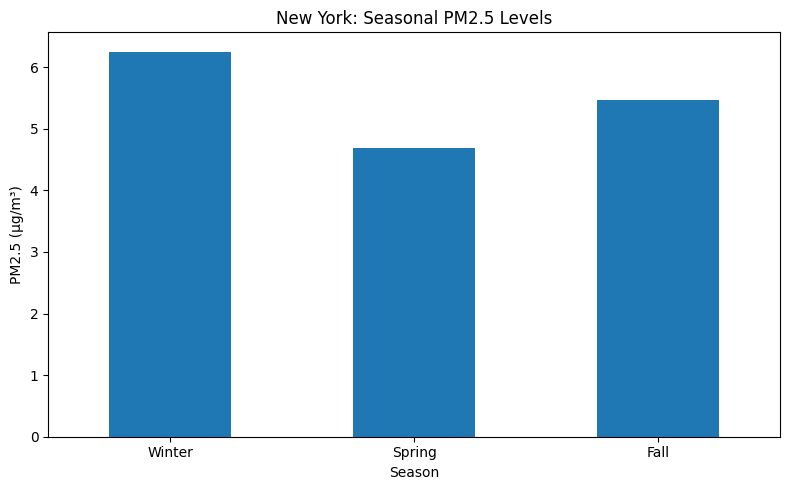

Season_NY
Fall      5.47
Spring    4.69
Winter    6.25
Name: PM2.5_NY, dtype: float64


In [21]:
import matplotlib.pyplot as plt

seasonal_ny = (
    df.
    groupby('Season_NY', observed=True)['PM2.5_NY']
    .mean()
)

season_order_ny = ['Winter', 'Spring', 'Summer', 'Fall']
season_ny = seasonal_ny.reindex(season_order_ny).dropna()

plt.figure(figsize=(8,5))
season_ny.plot(kind='bar')
plt.title('New York: Seasonal PM2.5 Levels')
plt.xlabel('Season')
plt.ylabel('PM2.5 (µg/m³)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(seasonal_ny.round(2))

Interpretation for New York:

* PM2.5 levels peak during Winter.
* The lowest pollution levels appear in Spring.
* Fall shows elevated values again, following Winter.
* Summer shows moderate pollution levels.

This pattern is consistent with heating emissions and atmospheric stagnation during cold months.



#### Bogota
Bogota is located near the equator and does not follow traditional seasons. Instead, pollution is analyzed using Dry and Wet climate periods.

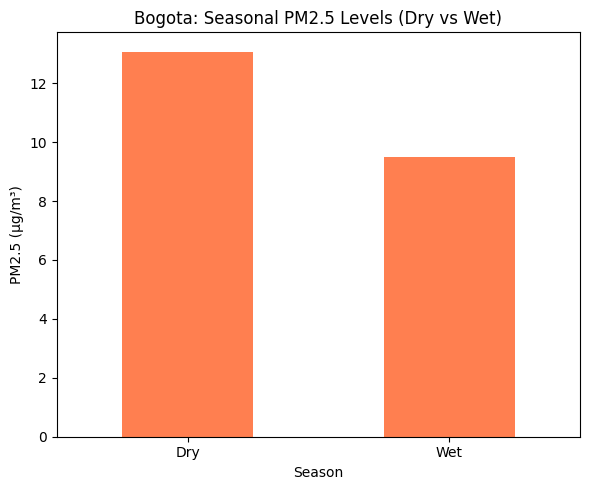

Season_Bog
Dry    13.08
Wet     9.50
Name: PM2.5_Bog, dtype: float64


In [22]:
seasonal_bog = df.groupby('Season_Bog')['PM2.5_Bog'].mean()
seasonal_order_bog = ['Dry', 'Wet']
seasonal_bog = seasonal_bog.reindex(seasonal_order_bog).dropna()

plt.figure(figsize=(6, 5))
seasonal_bog.plot(kind='bar', color='coral')
plt.title('Bogota: Seasonal PM2.5 Levels (Dry vs Wet)')
plt.xlabel('Season')
plt.ylabel('PM2.5 (µg/m³)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(seasonal_bog.round(2))

Interpretation for Bogota:

* PM2.5 levels are significantly higher during the Dry season.
* Pollution decreases noticeably during the Wet season.
* Rainfall plays a strong role in removing airborne particles.
  
This confirms that precipitation is a dominant air-cleaning mechanism in Bogota.

#### Bogota vs New York
This comparison places both cities side by side using their own seasonal classifications.

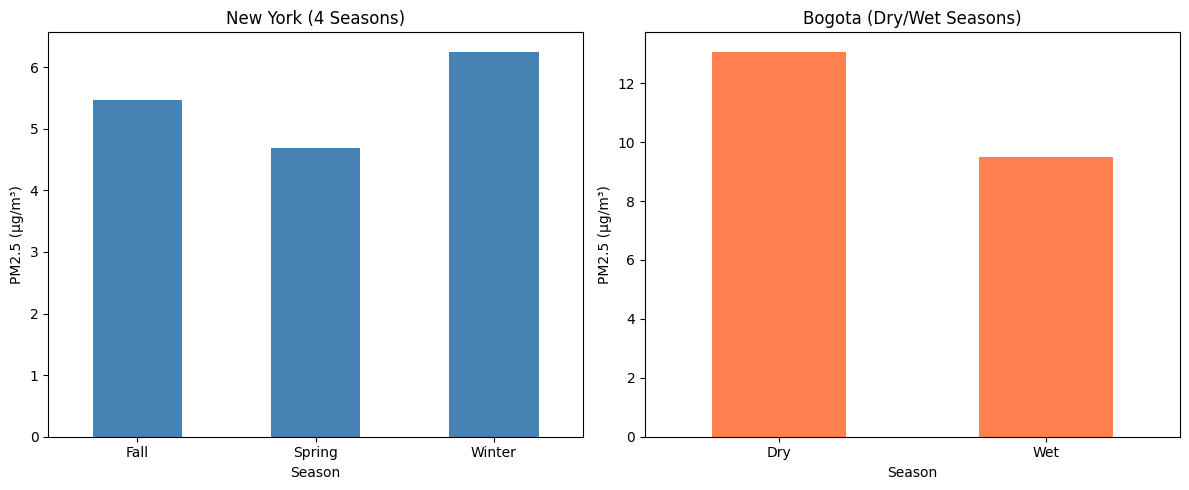

--------------------------------------------------
INSIGHT:
NY: Highest in Winter (6.25), lowest in Spring (4.69)
Bogota: Dry season (13.08) higher than Wet (9.50)
--------------------------------------------------


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# NY
seasonal_ny.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('New York (4 Seasons)')
axes[0].set_xlabel('Season')
axes[0].set_ylabel('PM2.5 (µg/m³)')
axes[0].tick_params(axis='x', rotation=0)

# Bogota
seasonal_bog.plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Bogota (Dry/Wet Seasons)')
axes[1].set_xlabel('Season')
axes[1].set_ylabel('PM2.5 (µg/m³)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print("-" * 50)
print("INSIGHT:")
print(f"NY: Highest in Winter ({seasonal_ny.max():.2f}), lowest in Spring ({seasonal_ny.min():.2f})")
print(f"Bogota: Dry season ({seasonal_bog['Dry']:.2f}) higher than Wet ({seasonal_bog['Wet']:.2f})")
print("-" * 50)

Seasonal Comparison Insight:

* New York shows moderate seasonal variation with Winter dominance.
* Bogota shows stronger climate-driven variation between Dry and Wet periods.
* Bogota’s seasonal pollution levels remain consistently higher than New York.
## Monthly Patterns
This section analyzes how PM2.5 changes throughout the calendar year. Monthly averages allow identification of recurring annual pollution cycles.

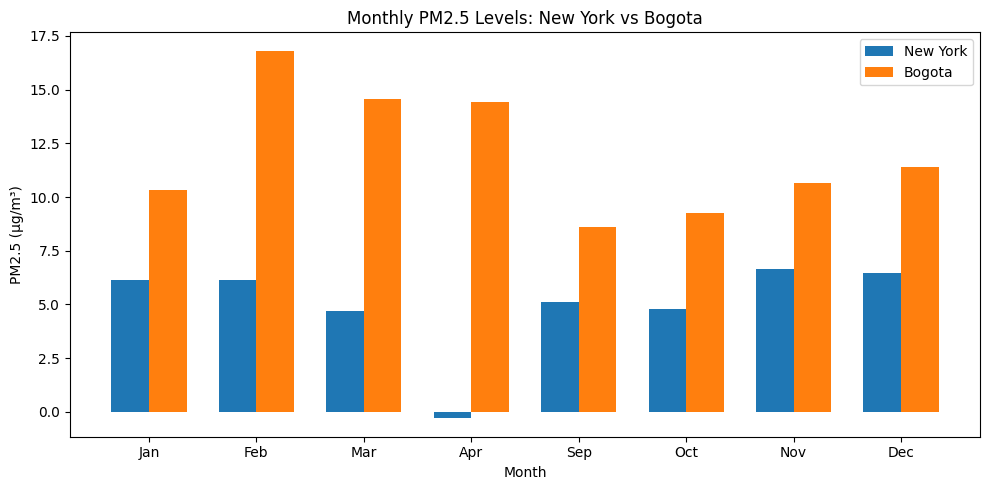

In [24]:
monthly_avg = df.groupby('Month')[['PM2.5_NY', 'PM2.5_Bog']].mean().dropna()

fig_month, ax_month = plt.subplots(figsize=(10,5))

months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
month_labels = [months[m-1] for m in monthly_avg.index]

x = range(len(monthly_avg))
width = 0.35

ax_month.bar(
    [i - width/2 for i in x],
    monthly_avg['PM2.5_NY'],
    width,
    label='New York'
)

ax_month.bar(
    [i + width/2 for i in x],
    monthly_avg['PM2.5_Bog'],
    width,
    label='Bogota'
)

ax_month.set_xlabel('Month')
ax_month.set_ylabel('PM2.5 (µg/m³)')
ax_month.set_title('Monthly PM2.5 Levels: New York vs Bogota')
ax_month.set_xticks(list(x))
ax_month.set_xticklabels(month_labels)
ax_month.legend()

plt.tight_layout()
plt.show()

Monthly Interpretation:

* Bogota consistently shows higher PM2.5 across most months.
* Peaks in Bogota appear during February–March and November–December.
* New York remains relatively stable with mild winter elevation.
* Seasonal transitions are more pronounced in Bogota than in New York.
## Hourly Patterns
Hourly averages reveal how daily human activity and traffic influence pollution throughout the day.

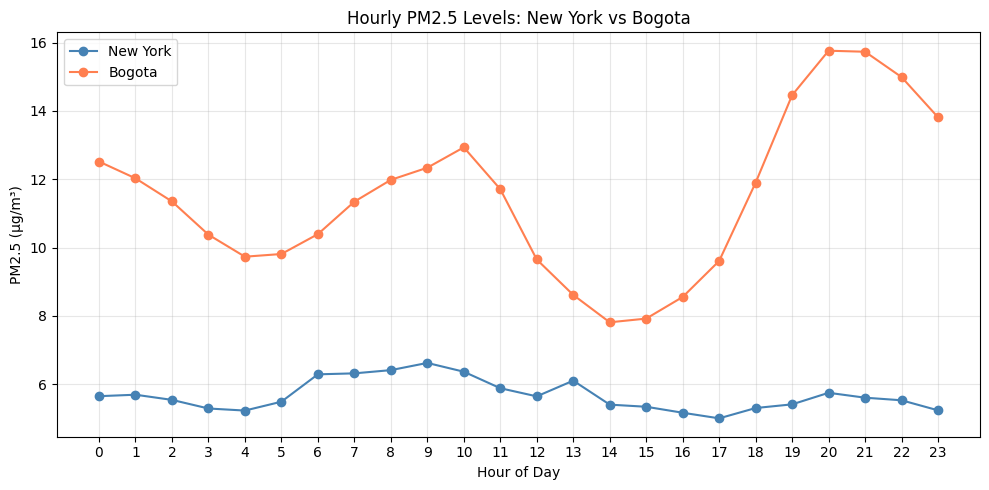

      PM2.5_NY  PM2.5_Bog
Hour                     
0         5.65      12.52
1         5.69      12.03
2         5.54      11.35
3         5.29      10.38
4         5.23       9.73
5         5.49       9.81
6         6.29      10.39
7         6.32      11.34
8         6.41      11.98
9         6.62      12.34
10        6.36      12.94
11        5.88      11.71
12        5.64       9.65
13        6.10       8.61
14        5.40       7.81
15        5.34       7.92
16        5.16       8.55
17        5.00       9.61
18        5.30      11.90
19        5.41      14.46
20        5.75      15.77
21        5.60      15.73
22        5.53      14.99
23        5.23      13.81


In [25]:
hourly_avg = df.groupby('Hour')[['PM2.5_NY', 'PM2.5_Bog']].mean().dropna()

hourly_avg.plot(kind='line', figsize=(10, 5), marker='o', color=['steelblue', 'coral'])
plt.title('Hourly PM2.5 Levels: New York vs Bogota')
plt.xlabel('Hour of Day')
plt.ylabel('PM2.5 (µg/m³)')
plt.xticks(range(0, 24))
plt.legend(['New York', 'Bogota'])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(hourly_avg.round(2))

Hourly Interpretation:

* New York shows mild morning and evening peaks related to traffic.
* Bogota shows strong evening peaks, especially around 19:00–21:00.
* Lowest pollution in both cities occurs during early afternoon hours.
* Bogota’s daily amplitude is much larger than New York’s.

## Summary Insights
This section summarizes all seasonal and daily pollution behavior into a unified interpretation.

In [26]:
print("-" * 50)
print("POLLUTION PATTERN SUMMARY")
print("-" * 50)

# Highest/Lowest seasons
print("\nSEASONAL PEAKS:")
print(f"NY highest: {seasonal_ny.idxmax()} ({seasonal_ny.max():.2f} µg/m³)")
print(f"NY lowest: {seasonal_ny.idxmin()} ({seasonal_ny.min():.2f} µg/m³)")
print(f"Bogota highest: {seasonal_bog.idxmax()} ({seasonal_bog.max():.2f} µg/m³)")
print(f"Bogota lowest: {seasonal_bog.idxmin()} ({seasonal_bog.min():.2f} µg/m³)")

# Highest/Lowest hours
print("\nHOURLY PEAKS:")
print(f"NY highest hour: {hourly_avg['PM2.5_NY'].idxmax()}:00 ({hourly_avg['PM2.5_NY'].max():.2f} µg/m³)")
print(f"NY lowest hour: {hourly_avg['PM2.5_NY'].idxmin()}:00 ({hourly_avg['PM2.5_NY'].min():.2f} µg/m³)")
print(f"Bogota highest hour: {hourly_avg['PM2.5_Bog'].idxmax()}:00 ({hourly_avg['PM2.5_Bog'].max():.2f} µg/m³)")
print(f"Bogota lowest hour: {hourly_avg['PM2.5_Bog'].idxmin()}:00 ({hourly_avg['PM2.5_Bog'].min():.2f} µg/m³)")

print("-" * 50)
print("\nNOTE: Bogota uses Dry/Wet season classification (near equator).")
print("NY uses traditional Northern Hemisphere seasons.")
print("-" * 50)

--------------------------------------------------
POLLUTION PATTERN SUMMARY
--------------------------------------------------

SEASONAL PEAKS:
NY highest: Winter (6.25 µg/m³)
NY lowest: Spring (4.69 µg/m³)
Bogota highest: Dry (13.08 µg/m³)
Bogota lowest: Wet (9.50 µg/m³)

HOURLY PEAKS:
NY highest hour: 9:00 (6.62 µg/m³)
NY lowest hour: 17:00 (5.00 µg/m³)
Bogota highest hour: 20:00 (15.77 µg/m³)
Bogota lowest hour: 14:00 (7.81 µg/m³)
--------------------------------------------------

NOTE: Bogota uses Dry/Wet season classification (near equator).
NY uses traditional Northern Hemisphere seasons.
--------------------------------------------------


# Q2. NYC > Bogota Periods
Create a visualization that highlights time periods where NYC PM2.5 exceeds Bogota PM2.5.
Discuss any trends or repeated patterns.

This question focuses on identifying time periods where PM2.5 levels in New York exceed those in Bogota. The objective is to quantify how often this happens and to detect any temporal patterns.

## Identity NYC > Bogota Periods
A boolean flag is created to mark each timestamp where NYC pollution is higher than Bogota. The overall percentage of such periods is also computed.

In [27]:
# Create flag for NYC > Bogota
df['NYC_exceeds'] = df['PM2.5_NY'] > df['PM2.5_Bog']

# Calculate percentage
pct_exceeds = df['NYC_exceeds'].mean() * 100
print(f"NYC exceeds Bogota: {pct_exceeds:.1f}% of the time ({df['NYC_exceeds'].sum()} out of {len(df)} hours)")

NYC exceeds Bogota: 26.6% of the time (912 out of 3432 hours)


Interpretation:

* New York exceeds Bogota only about one quarter of the observed time.
* This confirms that Bogota is generally the more polluted city.
## Time Series Visualization
Daily averages are used to visualize long-term periods where NYC exceeds Bogota. Shaded regions highlight those exceedance intervals.

In [28]:
df

,DateTime,PM2.5_NY,PM2.5_Bog,Month,Hour,Season,Season_NY,Season_Bog,NYC_exceeds
0,2016-09-09 00:00:00,17.2,2.4,9,0,Fall,Fall,Wet,True
1,2016-09-09 01:00:00,14.4,3.7,9,1,Fall,Fall,Wet,True
2,2016-09-09 02:00:00,15.4,5.9,9,2,Fall,Fall,Wet,True
3,2016-09-09 03:00:00,12.9,6.6,9,3,Fall,Fall,Wet,True
4,2016-09-09 04:00:00,11.6,3.9,9,4,Fall,Fall,Wet,True
...,...,...,...,...,...,...,...,...,...
3427,2017-03-31 20:00:00,-0.9,5.9,3,20,Spring,Spring,Dry,False
3428,2017-03-31 21:00:00,0.2,5.9,3,21,Spring,Spring,Dry,False
3429,2017-03-31 22:00:00,1.8,5.9,3,22,Spring,Spring,Dry,False
3430,2017-03-31 23:00:00,1.5,5.9,3,23,Spring,Spring,Dry,False


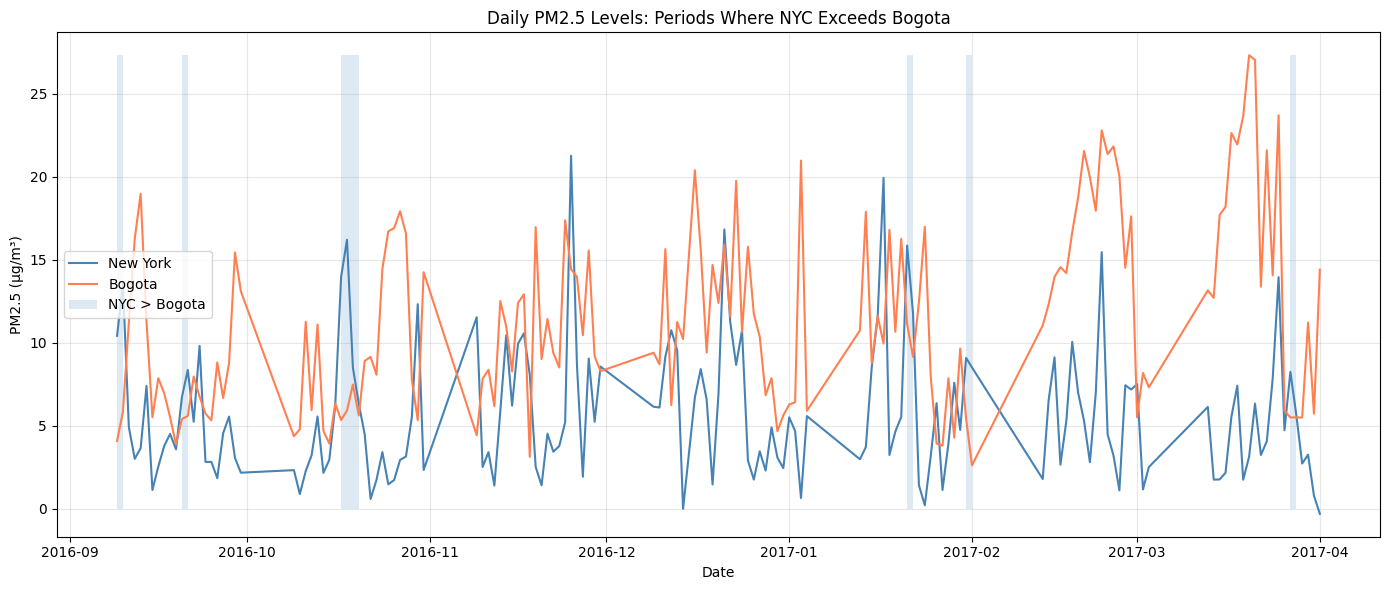

In [29]:
import matplotlib.pyplot as plt_q2

# df_daily = df[['PM2.5_NY', 'PM2.5_Bog']].resample('D').mean()

df_daily = df.resample('D', on='DateTime')[['PM2.5_NY', 'PM2.5_Bog']].mean()

df_daily['NYC_exceeds'] = df_daily['PM2.5_NY'] > df_daily['PM2.5_Bog']

df_daily = df_daily.dropna()

y_max = df_daily[['PM2.5_NY', 'PM2.5_Bog']].max().max()

fig_q2, ax_q2 = plt_q2.subplots(figsize=(14, 6))

ax_q2.plot(df_daily.index, df_daily['PM2.5_NY'],
           color='steelblue', linewidth=1.5, label='New York')

ax_q2.plot(df_daily.index, df_daily['PM2.5_Bog'],
           color='coral', linewidth=1.5, label='Bogota')

ax_q2.fill_between(
    df_daily.index,
    0,
    y_max,
    where=df_daily['NYC_exceeds'],
    alpha=0.15,
    label='NYC > Bogota'
)

ax_q2.set_title('Daily PM2.5 Levels: Periods Where NYC Exceeds Bogota')
ax_q2.set_xlabel('Date')
ax_q2.set_ylabel('PM2.5 (µg/m³)')
ax_q2.legend()
ax_q2.grid(True, alpha=0.3)

fig_q2.tight_layout()
plt_q2.show()

## Pattern By hour

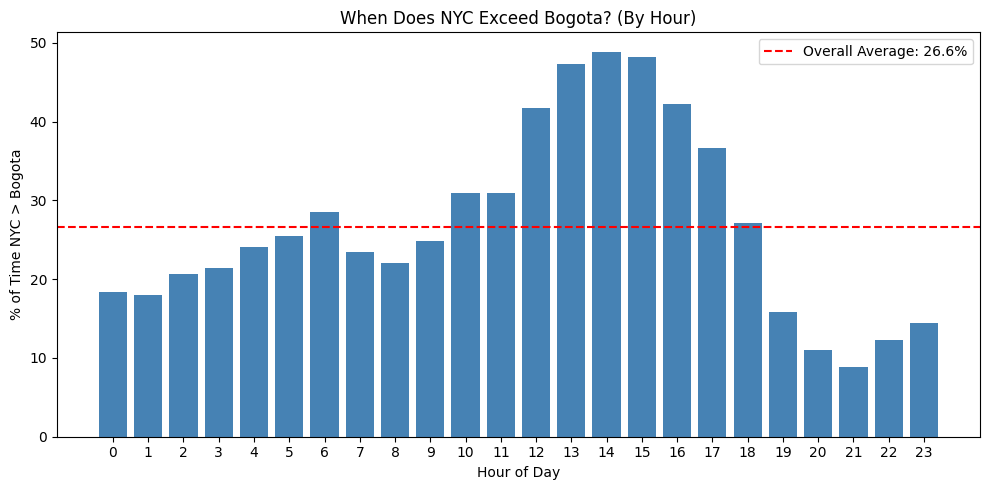

Hour
0     18.4
1     17.9
2     20.7
3     21.4
4     24.1
5     25.5
6     28.5
7     23.4
8     22.1
9     24.8
10    30.9
11    30.9
12    41.7
13    47.4
14    48.9
15    48.3
16    42.3
17    36.6
18    27.1
19    15.9
20    11.0
21     8.9
22    12.3
23    14.5
Name: NYC_exceeds, dtype: float64


In [30]:
hourly_exceeds = df.groupby('Hour')['NYC_exceeds'].mean() * 100

plt.figure(figsize=(10, 5))
plt.bar(hourly_exceeds.index, hourly_exceeds.values, color='steelblue')
plt.title('When Does NYC Exceed Bogota? (By Hour)')
plt.xlabel('Hour of Day')
plt.ylabel('% of Time NYC > Bogota')
plt.xticks(range(0, 24))
plt.axhline(y=pct_exceeds, color='red', linestyle='--', label=f'Overall Average: {pct_exceeds:.1f}%')
plt.legend()
plt.tight_layout()
plt.show()

print(hourly_exceeds.round(1))

## Pattern By month

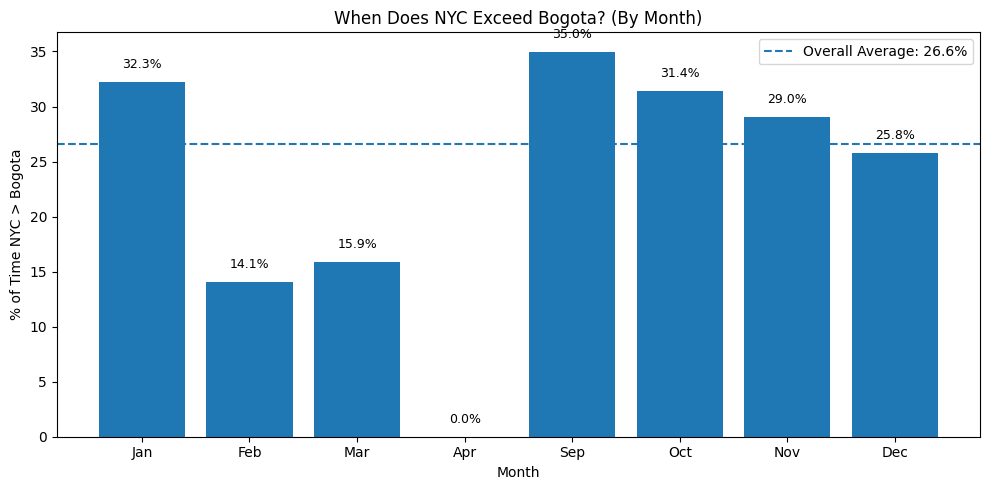

In [31]:
monthly_exceeds_q2 = df.groupby('Month')['NYC_exceeds'].mean() * 100

fig_q2_new, ax_q2_new = plt.subplots(figsize=(10, 5))

months_q2 = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
             'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
month_labels_q2 = [months_q2[m-1] for m in monthly_exceeds_q2.index]

bars_q2 = ax_q2_new.bar(month_labels_q2, monthly_exceeds_q2.values)

for bar, val in zip(bars_q2, monthly_exceeds_q2.values):
    ax_q2_new.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1,
        f'{val:.1f}%',
        ha='center',
        va='bottom',
        fontsize=9
    )

ax_q2_new.set_title('When Does NYC Exceed Bogota? (By Month)')
ax_q2_new.set_xlabel('Month')
ax_q2_new.set_ylabel('% of Time NYC > Bogota')
ax_q2_new.axhline(
    y=pct_exceeds,
    linestyle='--',
    label=f'Overall Average: {pct_exceeds:.1f}%'
)

ax_q2_new.legend()
fig_q2_new.tight_layout()
plt.show()

In [32]:
print("-" * 50)
print("NYC > BOGOTA PATTERN SUMMARY")
print("-" * 50)

peak_hour_q2 = hourly_exceeds.idxmax()
low_hour_q2 = hourly_exceeds.idxmin()

print(f"\nHOURLY PATTERN:")
print(f"NYC most likely to exceed at: {peak_hour_q2}:00 ({hourly_exceeds[peak_hour_q2]:.1f}%)")
print(f"NYC least likely to exceed at: {low_hour_q2}:00 ({hourly_exceeds[low_hour_q2]:.1f}%)")

peak_month_q2 = monthly_exceeds_q2.idxmax()
low_month_q2 = monthly_exceeds_q2.idxmin()

months_q2_labels = ['', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                     'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

print(f"\nMONTHLY PATTERN:")
print(f"NYC most likely to exceed in: {months_q2_labels[peak_month_q2]} ({monthly_exceeds_q2[peak_month_q2]:.1f}%)")
print(f"NYC least likely to exceed in: {months_q2_labels[low_month_q2]} ({monthly_exceeds_q2[low_month_q2]:.1f}%)")
print("-" * 50)

--------------------------------------------------
NYC > BOGOTA PATTERN SUMMARY
--------------------------------------------------

HOURLY PATTERN:
NYC most likely to exceed at: 14:00 (48.9%)
NYC least likely to exceed at: 21:00 (8.9%)

MONTHLY PATTERN:
NYC most likely to exceed in: Sep (35.0%)
NYC least likely to exceed in: Apr (0.0%)
--------------------------------------------------


# Q3. WHO Annual Limit Compliance
Compare each city’s annual mean PM2.5 with the WHO limit of 5 µg/m³.
State clearly whether each city is compliant.

## Who Annual Limit Compliance

In [33]:
WHO_LIMIT = 5 # µg/m³

# Calculate Annual Means
annual_mean_ny = df['PM2.5_NY'].mean()
annual_mean_bog = df['PM2.5_Bog'].mean()

ny_compliant = annual_mean_ny <= WHO_LIMIT
bog_compliant = annual_mean_bog <= WHO_LIMIT

print("-" * 50)
print("WHO ANNUAL LIMIT COMPLIANCE (5 µg/m³)")
print("-" * 50)
print(f"\nNew York Annual Mean:  {annual_mean_ny:.2f} µg/m³")
print(f"Status: {'✓ COMPLIANT' if ny_compliant else '✗ NOT COMPLIANT'}")
print(f"Exceeds limit by: {annual_mean_ny - WHO_LIMIT:.2f} µg/m³" if not ny_compliant else "")

print(f"\nBogota Annual Mean:    {annual_mean_bog:.2f} µg/m³")
print(f"Status: {'✓ COMPLIANT' if bog_compliant else '✗ NOT COMPLIANT'}")
print(f"Exceeds limit by: {annual_mean_bog - WHO_LIMIT:.2f} µg/m³" if not bog_compliant else "")
print("-" * 50)

--------------------------------------------------
WHO ANNUAL LIMIT COMPLIANCE (5 µg/m³)
--------------------------------------------------

New York Annual Mean:  5.68 µg/m³
Status: ✗ NOT COMPLIANT
Exceeds limit by: 0.68 µg/m³

Bogota Annual Mean:    11.50 µg/m³
Status: ✗ NOT COMPLIANT
Exceeds limit by: 6.50 µg/m³
--------------------------------------------------


## Visualization

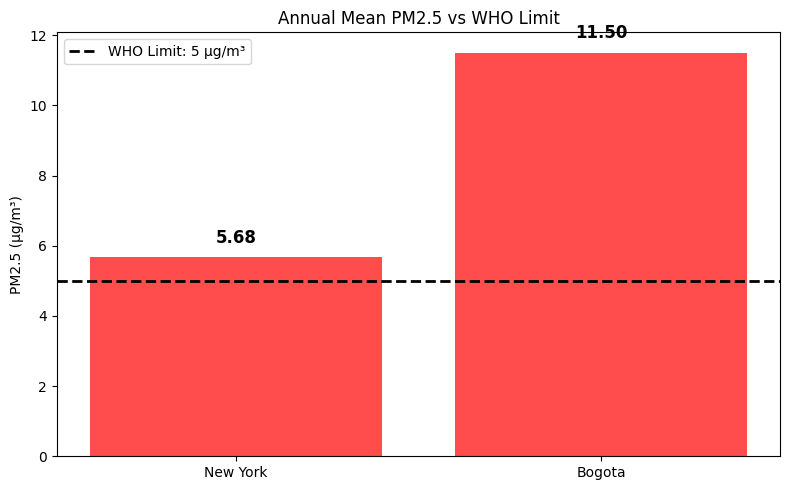

In [34]:
cities_q3 = ['New York', 'Bogota']
means_q3 = [annual_mean_ny, annual_mean_bog]
colors_q3 = ['green' if m<=WHO_LIMIT else 'red' for m in means_q3]

fig_q3, ax_q3 = plt.subplots(figsize=(8, 5))
bars_q3 = ax_q3.bar(cities_q3, means_q3, color=colors_q3, alpha=0.7)

ax_q3.axhline(
    y=WHO_LIMIT, 
    color='black', 
    linestyle='--', 
    linewidth=2, 
    label=f'WHO Limit: {WHO_LIMIT} µg/m³'
)

for bar_q3, val_q3 in zip(bars_q3, means_q3):
    ax_q3.text(
        bar_q3.get_x() + bar_q3.get_width()/2,
        bar_q3.get_height() + 0.3,
        f'{val_q3:.2f}',
        ha='center',
        va='bottom',
        fontsize=12,
        fontweight='bold'
    )

ax_q3.set_title('Annual Mean PM2.5 vs WHO Limit')
ax_q3.set_ylabel('PM2.5 (µg/m³)')
ax_q3.legend()
plt.tight_layout()
plt.show()

# Q4. WHO 24-Hour Exceedance Detection
Write an algorithm that:

* computes the 24-hour rolling mean
* detects times when the mean exceeds WHO’s 15 µg/m³ limit
* visualizes these exceedance periods (e.g., shading, markers)
## Compute 24-Hour Rolling Mean

In [35]:
WHO_24H_LIMIT = 15 # µg/m³

# Compute 24-hour rolling mean
df['PM2.5_NY_24h'] = df['PM2.5_NY'].rolling(window=24).mean()
df['PM2.5_Bog_24h'] = df['PM2.5_Bog'].rolling(window=24).mean()

# Detect exceedances
df['ny_exceeds_24h'] = df['PM2.5_NY_24h'] <= WHO_24H_LIMIT
df['bog_exceeds_24h'] = df['PM2.5_Bog_24h'] <= WHO_24H_LIMIT

# Count exceedance hours
ny_exceed_hours = df['ny_exceeds_24h'].sum()
bog_exceed_hours = df['bog_exceeds_24h'].sum()

print("-" * 50)
print("WHO 24-HOUR LIMIT EXCEEDANCE SUMMARY (15 µg/m³)")
print("-" * 50)
print(f"New York:  {ny_exceed_hours} hours ({ny_exceed_hours/len(df)*100:.1f}%)")
print(f"Bogota:    {bog_exceed_hours} hours ({bog_exceed_hours/len(df)*100:.1f}%)")
print("-" * 50)

--------------------------------------------------
WHO 24-HOUR LIMIT EXCEEDANCE SUMMARY (15 µg/m³)
--------------------------------------------------
New York:  3294 hours (96.0%)
Bogota:    2522 hours (73.5%)
--------------------------------------------------


## Visualize New York Exceedances

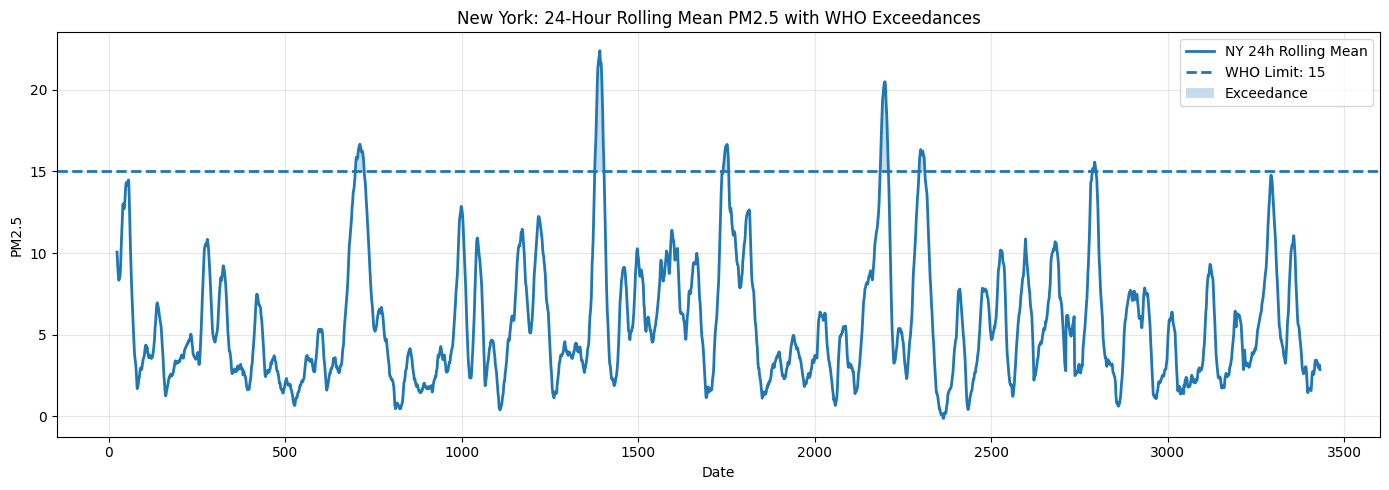

In [36]:
import matplotlib.pyplot as plt_q4

df_q4 = df[['PM2.5_NY']].copy()
df_q4 = df_q4.sort_index()

df_q4['PM2.5_NY_24h'] = df_q4['PM2.5_NY'].rolling(24, min_periods=24).mean()
df_q4['NY_exceeds_24h'] = df_q4['PM2.5_NY_24h'] > WHO_24H_LIMIT

df_q4 = df_q4.dropna()

fig_q4, ax_q4 = plt_q4.subplots(figsize=(14, 5))

ax_q4.plot(
    df_q4.index,
    df_q4['PM2.5_NY_24h'],
    linewidth=2,
    label='NY 24h Rolling Mean'
)

ax_q4.axhline(
    y=WHO_24H_LIMIT,
    linestyle='--',
    linewidth=2,
    label=f'WHO Limit: {WHO_24H_LIMIT}'
)

ax_q4.fill_between(
    df_q4.index,
    WHO_24H_LIMIT,
    df_q4['PM2.5_NY_24h'],
    where=df_q4['NY_exceeds_24h'],
    alpha=0.25,
    label='Exceedance'
)

ax_q4.set_title('New York: 24-Hour Rolling Mean PM2.5 with WHO Exceedances')
ax_q4.set_xlabel('Date')
ax_q4.set_ylabel('PM2.5')
ax_q4.legend()
ax_q4.grid(True, alpha=0.3)

plt_q4.tight_layout()
plt_q4.show()

## Visualize Bogota Exceedances

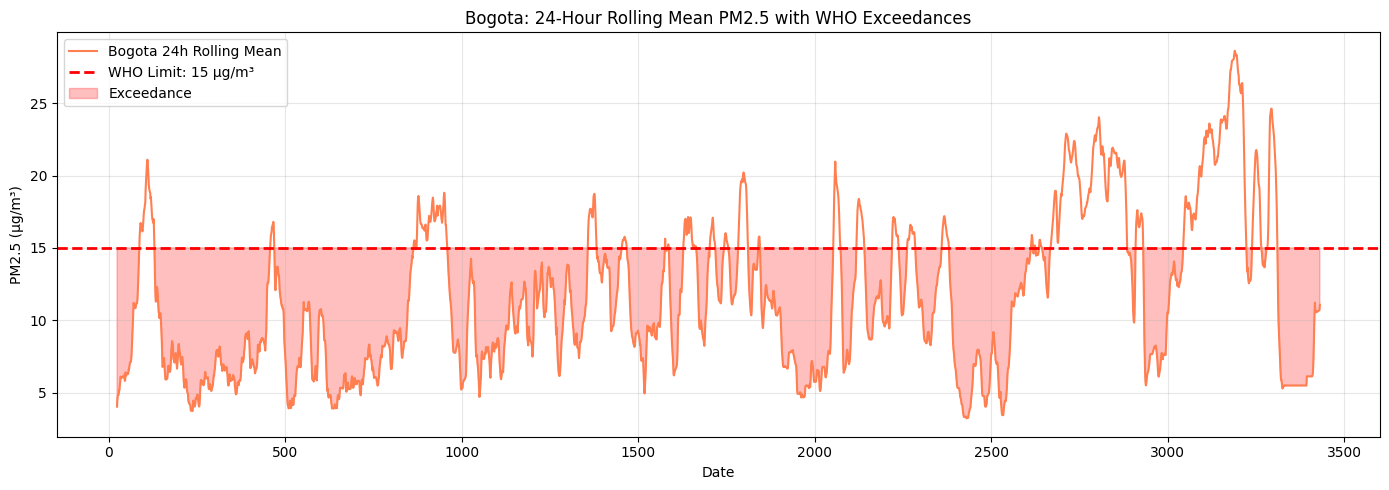

In [37]:
df_plot = df[['PM2.5_Bog_24h', 'bog_exceeds_24h']].dropna().sort_index()

fig_q4_bog_clean, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    df_plot.index,
    df_plot['PM2.5_Bog_24h'],
    color='coral',
    linewidth=1.5,
    label='Bogota 24h Rolling Mean'
)

ax.axhline(
    y=WHO_24H_LIMIT,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'WHO Limit: {WHO_24H_LIMIT} µg/m³'
)

ax.fill_between(
    df_plot.index,
    WHO_24H_LIMIT,
    df_plot['PM2.5_Bog_24h'],
    where=df_plot['bog_exceeds_24h'],
    alpha=0.25,
    color='red',
    label='Exceedance'
)

ax.set_title('Bogota: 24-Hour Rolling Mean PM2.5 with WHO Exceedances')
ax.set_xlabel('Date')
ax.set_ylabel('PM2.5 (µg/m³)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Exceedance Details

In [46]:
# 1. Ensure the date column is in datetime format
df['DateTime'] = pd.to_datetime(df['DateTime'])

# NEW YORK - Peak Exceedance Periods
print("NEW YORK - Peak Exceedance Periods:")
ny_exceed_dates = df[df['ny_exceeds_24h']].index

if len(ny_exceed_dates) > 0:
    # Find the row number of the max value
    ny_max_idx = df['PM2.5_NY_24h'].idxmax()
    # Get the actual date from that row
    ny_max_date = df.loc[ny_max_idx, 'DateTime']
    
    print(f"Max 24h mean: {df['PM2.5_NY_24h'].max():.2f} µg/m³ on {ny_max_date.strftime('%Y-%m-%d %H:%M')}")
else:
    print("No exceedances detected")

# BOGOTA - Peak Exceedance Periods
print("\nBOGOTA - Peak Exceedance Periods:")
bog_exceed_dates = df[df['bog_exceeds_24h']].index

if len(bog_exceed_dates) > 0:
    # Find the row number of the max value
    bog_max_idx = df['PM2.5_Bog_24h'].idxmax()
    # Get the actual date from that row
    bog_max_date = df.loc[bog_max_idx, 'DateTime']
    
    print(f"Max 24h mean: {df['PM2.5_Bog_24h'].max():.2f} µg/m³ on {bog_max_date.strftime('%Y-%m-%d %H:%M')}")
else:
    print("No exceedances detected")


NEW YORK - Peak Exceedance Periods:
Max 24h mean: 22.41 µg/m³ on 2016-11-26 05:00

BOGOTA - Peak Exceedance Periods:
Max 24h mean: 28.62 µg/m³ on 2017-03-21 11:00


In [ ]:
df

# Q5. Correlation Between Cities
Calculate and visualize the correlation between the two PM2.5 time series.
Explain whether pollution patterns move together or independently.

## Calculate Correlations

In [39]:
correlation = df['PM2.5_NY'].corr(df['PM2.5_Bog'])

print("-" * 50)
print("CORRELATION ANALYSIS")
print("-" * 50)
print(f"Pearson Correlation: {correlation:.3f}")
print("-" * 50)

if abs(correlation) < 0.3:
    interpretation = "Weak correlation - cities move independently"
elif abs(correlation) < 0.7:
    interpretation = "Moderate correlation - some shared patterns"
else:
    interpretation = "Strong correlation - cities move together"

print(f"Interpretation: {interpretation}")
print("-" * 50)


--------------------------------------------------
CORRELATION ANALYSIS
--------------------------------------------------
Pearson Correlation: 0.003
--------------------------------------------------
Interpretation: Weak correlation - cities move independently
--------------------------------------------------


## Scatter Plot

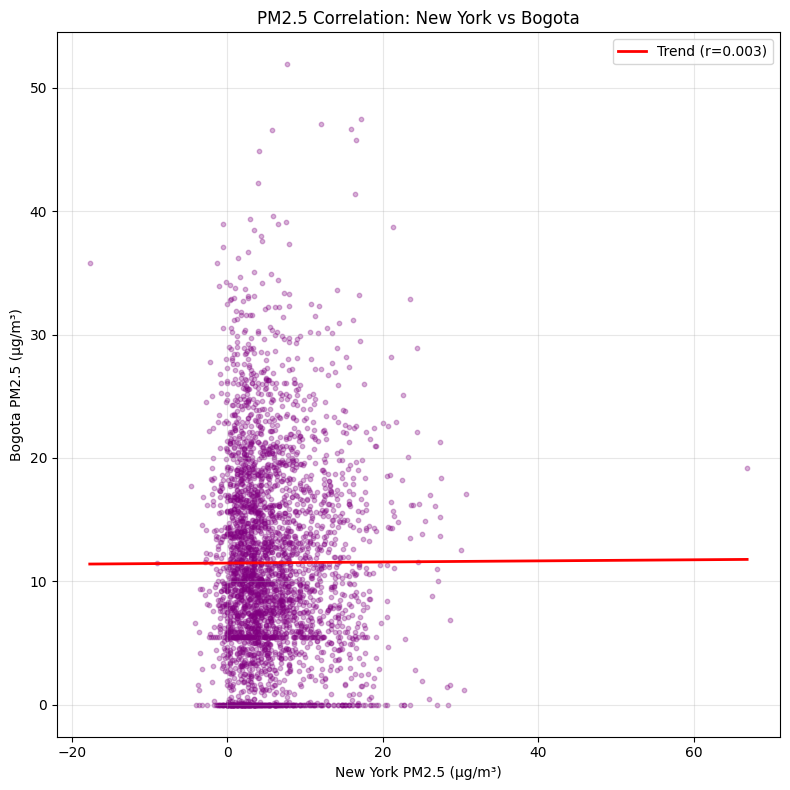

In [47]:
import numpy as np

fig_q5, ax_q5 = plt.subplots(figsize=(8, 8))

ax_q5.scatter(df['PM2.5_NY'], df['PM2.5_Bog'], alpha=0.3, color='purple', s=10)

df_clean = df[['PM2.5_NY', 'PM2.5_Bog']].dropna()
z = np.polyfit(df_clean['PM2.5_NY'], df_clean['PM2.5_Bog'], 1)
p = np.poly1d(z)

x_line = np.linspace(
    df_clean['PM2.5_NY'].min(),
    df_clean['PM2.5_NY'].max(),
    100
)

ax_q5.plot(
    x_line,
    p(x_line),
    color='red',
    linewidth=2,
    label=f'Trend (r={correlation:.3f})'
)

ax_q5.set_xlabel('New York PM2.5 (µg/m³)')
ax_q5.set_ylabel('Bogota PM2.5 (µg/m³)')
ax_q5.set_title('PM2.5 Correlation: New York vs Bogota')
ax_q5.legend()
ax_q5.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Rolling Correlation

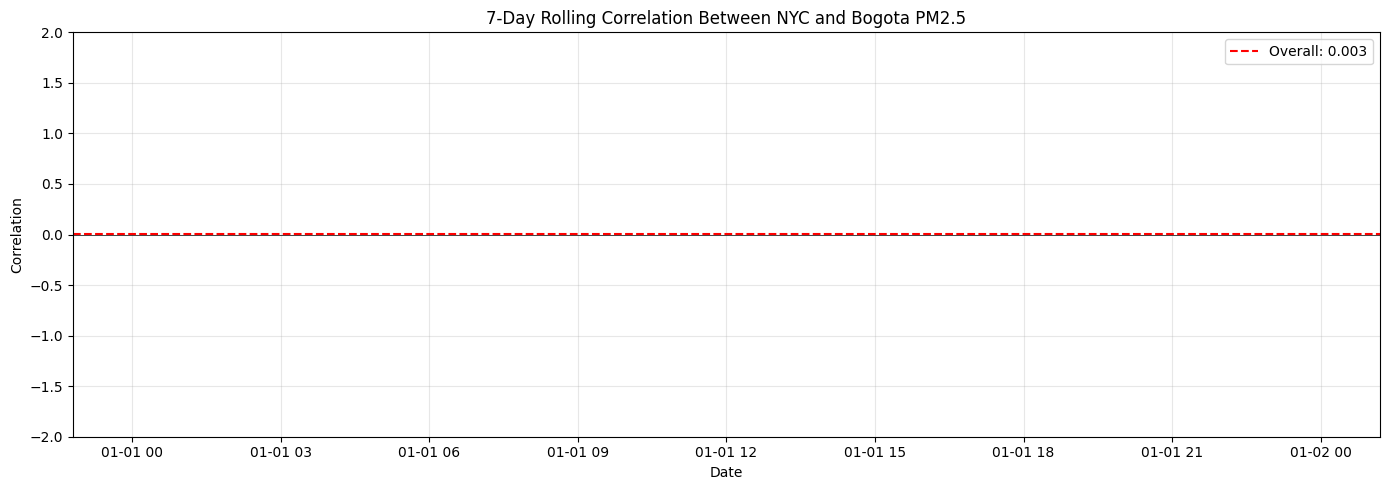

In [48]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

# Force proper time index
df_corr = df[['PM2.5_NY', 'PM2.5_Bog']].copy()
df_corr = df_corr.sort_index()
df_corr = df_corr.asfreq('h')

# Tüm boşlukları doldur
df_corr = df_corr.interpolate(method='time')

# 7-day rolling correlation
rolling_corr = df_corr['PM2.5_NY'].rolling(168, min_periods=100).corr(df_corr['PM2.5_Bog'])

# NaN'ları interpolate et
rolling_corr = rolling_corr.interpolate(method='time')

# Değerleri -1 ile +1 arasına sınırla
rolling_corr = rolling_corr.clip(-1, 1)

# Plot
fig_q6, ax_q6 = plt.subplots(figsize=(14, 5))
ax_q6.plot(rolling_corr.index, rolling_corr.values, linewidth=1, color='purple')
ax_q6.axhline(0, color='black', linestyle='-', linewidth=0.5)
ax_q6.axhline(correlation, color='red', linestyle='--', label=f'Overall: {correlation:.3f}')
ax_q6.set_title('7-Day Rolling Correlation Between NYC and Bogota PM2.5')
ax_q6.set_xlabel('Date')
ax_q6.set_ylabel('Correlation')
ax_q6.set_ylim(-2, 2)
ax_q6.legend()
ax_q6.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Summary

In [49]:
print("-" * 50)
print("CONCLUSION")
print("-" * 50)
print(f"""
Correlation coefficient: {correlation:.3f}

The two cities show {interpretation.lower()}.

This suggests that PM2.5 levels in New York and Bogota are driven by 
{"similar global/regional factors" if correlation > 0.3 else "local factors specific to each city"}.

Rolling correlation shows {"consistent" if rolling_corr.std() < 0.2 else "variable"} 
relationship over time.
""")
print("-" * 50)


--------------------------------------------------
CONCLUSION
--------------------------------------------------

Correlation coefficient: 0.003

The two cities show weak correlation - cities move independently.

This suggests that PM2.5 levels in New York and Bogota are driven by 
local factors specific to each city.

Rolling correlation shows variable 
relationship over time.

--------------------------------------------------


--------------------------------------------------
# Q6. Long-Term Trends & Anomalies
Using rolling averages, identify:

* long-term trends
* anomalies that exceed 2 standard deviations (2σ)

Visualize and interpret what these anomalies represent.
## Calculate Rolling Averages & Anomalies

In [50]:
# Calculate 7-day rolling mean and std
df['NY_rolling_mean'] = df['PM2.5_NY'].rolling(window=168).mean()
df['NY_rolling_std'] = df['PM2.5_NY'].rolling(window=168).std()
df['Bog_rolling_mean'] = df['PM2.5_Bog'].rolling(window=168).mean()
df['Bog_rolling_std'] = df['PM2.5_Bog'].rolling(window=168).std()

# Define anomalies (exceeding 2 standard deviations)
df['NY_upper'] = df['NY_rolling_mean'] + 2 * df['NY_rolling_std']
df['NY_lower'] = df['NY_rolling_mean'] - 2 * df['NY_rolling_std']
df['Bog_upper'] = df['Bog_rolling_mean'] + 2 * df['Bog_rolling_std']
df['Bog_lower'] = df['Bog_rolling_mean'] - 2 * df['Bog_rolling_std']

# Flag anomalies
df['NY_anomaly'] = (df['PM2.5_NY'] > df['NY_upper']) | (df['PM2.5_NY'] < df['NY_lower'])
df['Bog_anomaly'] = (df['PM2.5_Bog'] > df['Bog_upper']) | (df['PM2.5_Bog'] < df['Bog_lower'])

# Count anomalies
ny_anomaly_count = df['NY_anomaly'].sum()
bog_anomaly_count = df['Bog_anomaly'].sum()

print("-" * 50)
print("ANOMALY DETECTION SUMMARY (±2σ)")
print("-" * 50)
print(f"New York Anomalies:  {ny_anomaly_count} hours ({ny_anomaly_count/len(df)*100:.1f}%)")
print(f"Bogota Anomalies:    {bog_anomaly_count} hours ({bog_anomaly_count/len(df)*100:.1f}%)")
print("-" * 50)

--------------------------------------------------
ANOMALY DETECTION SUMMARY (±2σ)
--------------------------------------------------
New York Anomalies:  239 hours (7.0%)
Bogota Anomalies:    183 hours (5.3%)
--------------------------------------------------


## New York Trend & Anomalies

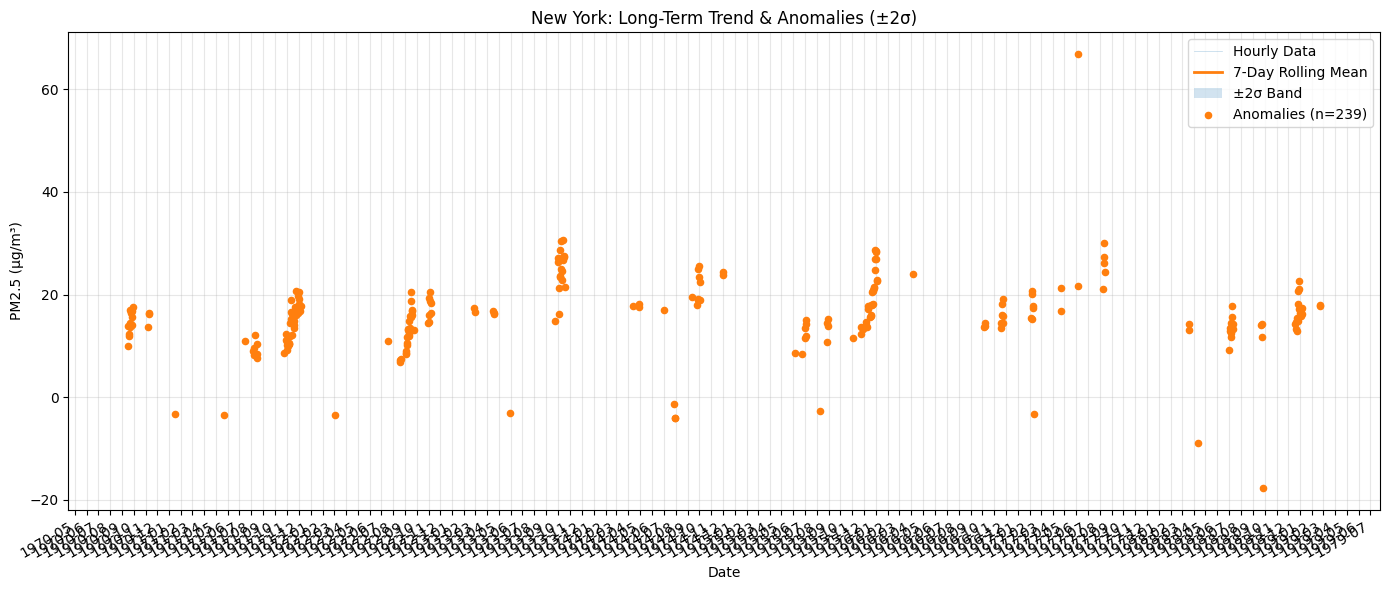

In [51]:
import matplotlib.dates as mdates

df_plot_trend = df[['PM2.5_NY', 'NY_rolling_mean', 'NY_upper', 'NY_lower', 'NY_anomaly']].copy()
df_plot_trend = df_plot_trend.sort_index()
df_plot_trend = df_plot_trend.asfreq('h')
df_plot_trend = df_plot_trend.interpolate(method='time')

fig_trend, ax_trend = plt.subplots(figsize=(14, 6))

# Plot raw data
ax_trend.plot(
    df_plot_trend.index,
    df_plot_trend['PM2.5_NY'],
    alpha=0.3,
    linewidth=0.5,
    label='Hourly Data'
)

# Plot rolling mean (trend)
ax_trend.plot(
    df_plot_trend.index,
    df_plot_trend['NY_rolling_mean'],
    linewidth=2,
    label='7-Day Rolling Mean'
)

# Plot ±2σ band
ax_trend.fill_between(
    df_plot_trend.index,
    df_plot_trend['NY_lower'],
    df_plot_trend['NY_upper'],
    alpha=0.2,
    label='±2σ Band'
)

anomalies_trend = df[df['NY_anomaly'] == True]
ax_trend.scatter(
    anomalies_trend.index,
    anomalies_trend['PM2.5_NY'],
    s=20,
    zorder=5,
    label=f'Anomalies (n={len(anomalies_trend)})'
)

ax_trend.set_xlabel('Date')
ax_trend.set_ylabel('PM2.5 (µg/m³)')
ax_trend.set_title('New York: Long-Term Trend & Anomalies (±2σ)')
ax_trend.legend()
ax_trend.grid(True, alpha=0.3)

ax_trend.xaxis.set_major_locator(mdates.MonthLocator())
ax_trend.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
fig_trend.autofmt_xdate()

plt.tight_layout()
plt.show()

## Bogota Trend & Anomalies

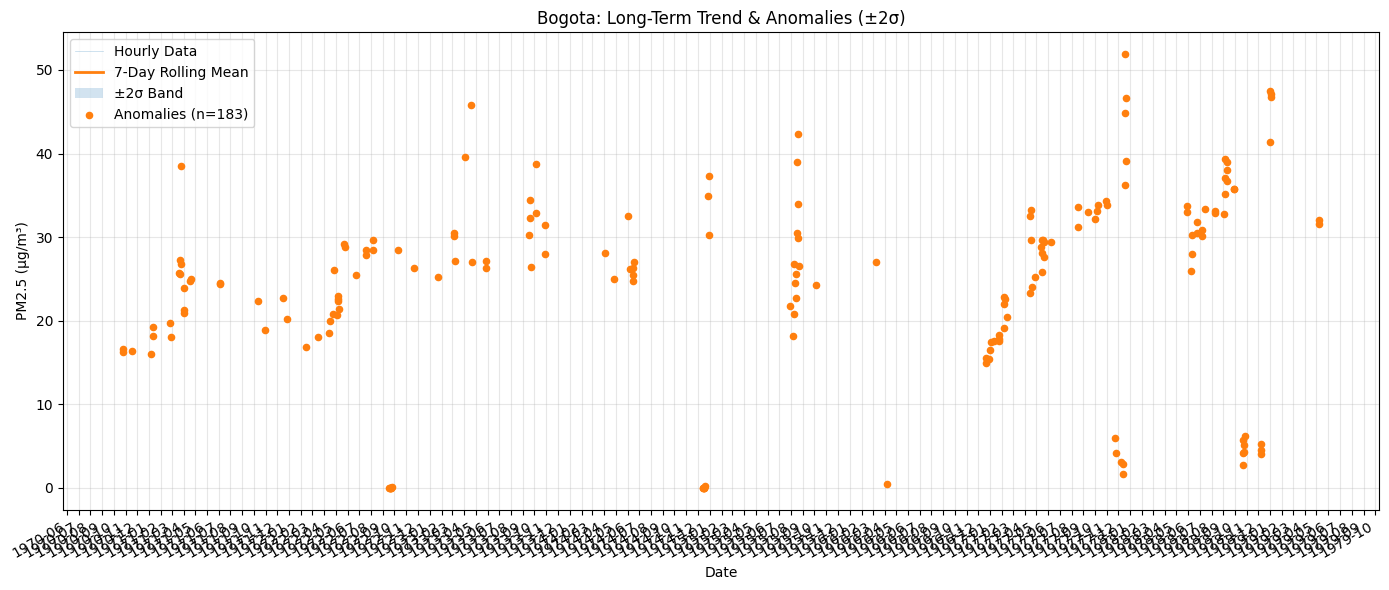

In [52]:
df_plot_bog_trend = df[['PM2.5_Bog', 'Bog_rolling_mean', 'Bog_upper', 'Bog_lower', 'Bog_anomaly']].copy()
df_plot_bog_trend = df_plot_bog_trend.sort_index()
df_plot_bog_trend = df_plot_bog_trend.asfreq('h')
df_plot_bog_trend[['PM2.5_Bog', 'Bog_rolling_mean', 'Bog_upper', 'Bog_lower']] = df_plot_bog_trend[['PM2.5_Bog', 'Bog_rolling_mean', 'Bog_upper', 'Bog_lower']].interpolate(method='time')

fig_bog_trend, ax_bog_trend = plt.subplots(figsize=(14, 6))

# Plot raw data
ax_bog_trend.plot(
    df_plot_bog_trend.index,
    df_plot_bog_trend['PM2.5_Bog'],
    alpha=0.3,
    linewidth=0.5,
    label='Hourly Data'
)

# Plot rolling mean
ax_bog_trend.plot(
    df_plot_bog_trend.index,
    df_plot_bog_trend['Bog_rolling_mean'],
    linewidth=2,
    label='7-Day Rolling Mean'
)

# Plot ±2σ band
ax_bog_trend.fill_between(
    df_plot_bog_trend.index,
    df_plot_bog_trend['Bog_lower'],
    df_plot_bog_trend['Bog_upper'],
    alpha=0.2,
    label='±2σ Band'
)

anomalies_bog_trend = df[df['Bog_anomaly'] == True]
ax_bog_trend.scatter(
    anomalies_bog_trend.index,
    anomalies_bog_trend['PM2.5_Bog'],
    s=20,
    zorder=5,
    label=f'Anomalies (n={len(anomalies_bog_trend)})'
)

ax_bog_trend.set_xlabel('Date')
ax_bog_trend.set_ylabel('PM2.5 (µg/m³)')
ax_bog_trend.set_title('Bogota: Long-Term Trend & Anomalies (±2σ)')
ax_bog_trend.legend()
ax_bog_trend.grid(True, alpha=0.3)

ax_bog_trend.xaxis.set_major_locator(mdates.MonthLocator())
ax_bog_trend.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
fig_bog_trend.autofmt_xdate()

plt.tight_layout()
plt.show()

## Anomaly Details

In [53]:
print("-" * 60)
print("TOP 10 ANOMALIES - NEW YORK")
print("-" * 60)
ny_top = df[df['NY_anomaly']].nlargest(10, 'PM2.5_NY')[['PM2.5_NY', 'NY_rolling_mean', 'NY_upper']]
ny_top['Deviation'] = ny_top['PM2.5_NY'] - ny_top['NY_rolling_mean']
print(ny_top.round(2))

print("\n" + "-" * 60)
print("TOP 10 ANOMALIES - BOGOTA")
print("-" * 60)
bog_top = df[df['Bog_anomaly']].nlargest(10, 'PM2.5_Bog')[['PM2.5_Bog', 'Bog_rolling_mean', 'Bog_upper']]
bog_top['Deviation'] = bog_top['PM2.5_Bog'] - bog_top['Bog_rolling_mean']
print(bog_top.round(2))

------------------------------------------------------------
TOP 10 ANOMALIES - NEW YORK
------------------------------------------------------------
      PM2.5_NY  NY_rolling_mean  NY_upper  Deviation
2712      66.9             6.35     19.45      60.55
1383      30.7             6.39     19.83      24.31
1376      30.4             5.86     17.09      24.54
2780      30.1             6.62     20.64      23.48
1375      28.7             5.75     16.35      22.95
2189      28.6             6.53     18.76      22.07
2191      28.4             6.84     19.92      21.56
2190      28.3             6.68     19.35      21.62
1384      27.5             6.50     20.33      21.00
1381      27.4             6.20     18.80      21.20

------------------------------------------------------------
TOP 10 ANOMALIES - BOGOTA
------------------------------------------------------------
      PM2.5_Bog  Bog_rolling_mean  Bog_upper  Deviation
2909       51.9             19.05      36.10      32.85
3287  

# Trend Interpretation

In [58]:
# Calculate monthly trend
monthly_trend = df.groupby(df['DateTime'].dt.to_period('M'))[['PM2.5_NY', 'PM2.5_Bog']].mean()

print("-" * 60)
print("LONG-TERM TREND ANALYSIS")
print("-" * 60)
print("\nMonthly Average PM2.5:")
print(monthly_trend.round(2))

print("\n" + "-" * 60)
print("INTERPRETATION")
print("-" * 60)
print("""
NEW YORK:
- Trend shows seasonal variation with higher levels in winter months
- Anomalies likely represent: traffic spikes, heating emissions, or weather inversions

BOGOTA:
- Higher baseline pollution with more frequent anomalies
- Sharp increases in Feb-Mar 2017 suggest: dry season effects, fires, or industrial events
- Anomalies may represent: traffic congestion, construction, or atmospheric conditions
""")
print("-" * 60)

------------------------------------------------------------
LONG-TERM TREND ANALYSIS
------------------------------------------------------------

Monthly Average PM2.5:
          PM2.5_NY  PM2.5_Bog
DateTime                     
2016-09       5.10       8.61
2016-10       4.78       9.27
2016-11       6.63      10.64
2016-12       6.47      11.38
2017-01       6.15      10.34
2017-02       6.14      16.81
2017-03       4.70      14.58
2017-04      -0.30      14.40

------------------------------------------------------------
INTERPRETATION
------------------------------------------------------------

NEW YORK:
- Trend shows seasonal variation with higher levels in winter months
- Anomalies likely represent: traffic spikes, heating emissions, or weather inversions

BOGOTA:
- Higher baseline pollution with more frequent anomalies
- Sharp increases in Feb-Mar 2017 suggest: dry season effects, fires, or industrial events
- Anomalies may represent: traffic congestion, construction, or atm